In [169]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import Polynomial
import json
from glob import glob
from progress.bar import Bar
import pandas as pd
from scipy import stats 

In [2]:
results = []
files = glob("experiment_results/*")
with Bar("Loading Results", max = len(files)) as bar:
    for file in files:
        with open(file) as f:
            results.append((file, json.loads(f.read().replace("inf", "Infinity"))))
            # try:
            #     results.append(json.load(f))
            # except:
            #     print(file)
            #     results.append(json.loads(f.read().replace("inf", "Infinity")))
        bar.next()

In [3]:
files

['experiment_results/den520d_47_79_156_216_sipp_0_784_0.outai13',
 'experiment_results/den520d_88_33_12_177_sipp_0_837_0.outai6',
 'experiment_results/den520d_220_51_214_123_sipp_0_188_0.outai14',
 'experiment_results/den520d_17_187_215_203_sipp_0_549_0.outai14',
 'experiment_results/den520d_200_68_76_45_sipp_0_340_0.outai12',
 'experiment_results/den520d_127_168_152_45_sipp_0_368_0.outai12',
 'experiment_results/den520d_245_10_203_192_sipp_0_563_0.outai9',
 'experiment_results/den520d_123_231_113_103_sipp_0_538_0.outai3',
 'experiment_results/den520d_18_182_120_39_sipp_0_735_0.outai4',
 'experiment_results/den520d_115_88_119_92_sipp_0_17_0.outai6',
 'experiment_results/den520d_40_161_153_108_sipp_0_406_0.outai8',
 'experiment_results/den520d_29_175_19_76_sipp_0_798_0.outai13',
 'experiment_results/den520d_84_197_236_39_sipp_0_600_0.outai4',
 'experiment_results/den520d_88_46_37_164_sipp_0_726_0.outai12',
 'experiment_results/den520d_97_190_70_135_sipp_0_166_0.outai5',
 'experiment_res

In [4]:
res = results[1]
res

('experiment_results/den520d_88_33_12_177_sipp_0_837_0.outai6',
 {'filename': 'maps/den520/den520d.map',
  'algorithm': 'sipp',
  'seed': 0,
  'scenario': {'start_x': 88, 'start_y': 33, 'goal_x': 12, 'goal_y': 177},
  'results': [{'arrival_time': 379.266,
    'metadata': {'generated': 331663,
     'decreased': 10064,
     'expanded': 315422,
     'learnexpanded': 0,
     'searchruntime_ms': 299.019,
     'learnruntime_ms': 0}}]})

In [3]:
columns = [
    "filename",
    "algorithm",
    "seed",
    "start_x", "start_y", "goal_x", "goal_y",
    "sum_generated",
    "sum_decreased",
    "sum_expanded",
    "n_tref",
    "runtime",
    "node",
    "arrival_time",
    "instance_id",
    "replicate"
]

def process_results(results):
    n_tref = 0
    sum_gen = 0
    sum_dec = 0
    sum_exp = 0
    runtime = 0.0
    for r in results:
        n_tref += 1
        sum_gen += r['metadata']['generated']
        sum_dec += r['metadata']['decreased']
        sum_exp += r['metadata']['expanded']
        runtime += r['metadata']['searchruntime_ms']
    return sum_gen, sum_dec, sum_exp, n_tref, runtime

In [4]:
def mkrow(res):
    node = res[0].split(".out")[-1]
    rep = res[0].split(".out")[0].split("_")[-1]
    instance = res[0].split(".out")[0].split("_")[-2]
    res = res[1]
    arrival_time = None
    try:
        arrival_time = res['results'][0]['arrival_time']
    except:
        arrival_time = res['results'][0]['reference_time']
    return [res['filename'], res['algorithm'], res['seed'], res['scenario']['start_x'], res['scenario']['start_y'], res['scenario']['goal_x'], res['scenario']['goal_y'],
 *process_results(res['results']), node, arrival_time, instance, rep]

In [14]:
x = []
for res in results:
    x.append(mkrow(res))
data = pd.DataFrame(data = x, columns = columns)
data.instance_id = data.instance_id.astype(int)
data = data.sort_values("instance_id")

In [6]:
data.sum_generated.max()

np.int64(4109262757)

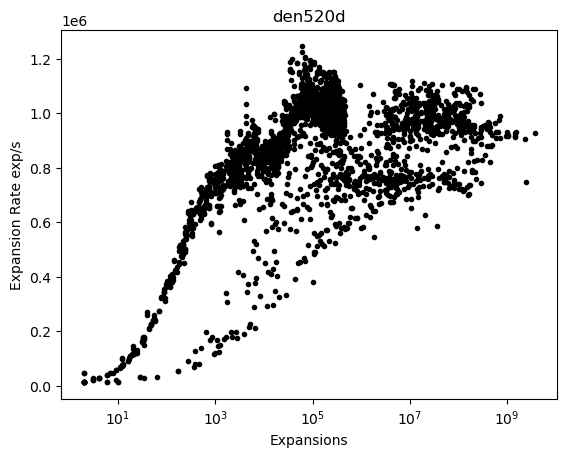

In [7]:
plt.plot(data.sum_expanded, data.sum_expanded/(data.runtime / 1000), ".k")
plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
plt.show()

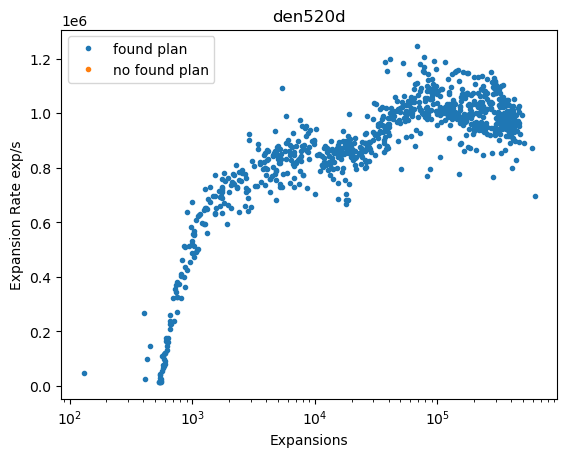

In [8]:
dat = data[(data.arrival_time < 1000) * (data.algorithm == "sipp")]
plt.plot(dat.sum_generated, dat.sum_expanded/(dat.runtime / 1000), ".", label = "found plan")
dat = data[(data.arrival_time >= 1000) * (data.algorithm == "sipp")]
plt.plot(dat.sum_generated, dat.sum_expanded/(dat.runtime / 1000), ".", label = "no found plan")

plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
#plt.ylim([400000, 1000000])
plt.legend()
plt.savefig("overhead2.png")

In [16]:
sipp_dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime,node,arrival_time,instance_id,replicate
2037,maps/den520/den520d.map,sipp,0,153,226,153,224,538,0,2,1,0.144433,ai1,2.04863,1,0
833,maps/den520/den520d.map,sipp,0,52,75,50,75,557,0,2,1,0.145548,ai2,2.00000,2,0
2393,maps/den520/den520d.map,sipp,0,93,228,92,225,554,0,4,1,0.151621,ai3,4.00000,3,0
1729,maps/den520/den520d.map,sipp,0,20,151,18,152,558,0,3,1,0.150416,ai4,3.00000,4,0
2170,maps/den520/den520d.map,sipp,0,17,176,15,173,550,0,7,1,0.153892,ai5,5.00000,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1449,maps/den520/den520d.map,sipp,0,242,5,17,199,246171,10058,223887,1,239.886000,ai11,420.05800,866,0
1020,maps/den520/den520d.map,sipp,0,10,204,78,36,421280,11237,403110,1,414.681000,ai9,412.66300,867,0
641,maps/den520/den520d.map,sipp,0,19,72,155,218,442246,12328,423437,1,510.546000,ai4,411.52600,868,0
1560,maps/den520/den520d.map,sipp,0,66,38,20,210,406252,11717,387416,1,386.148000,ai7,412.02400,869,0


-0.4941947278732419 6.138141001196567


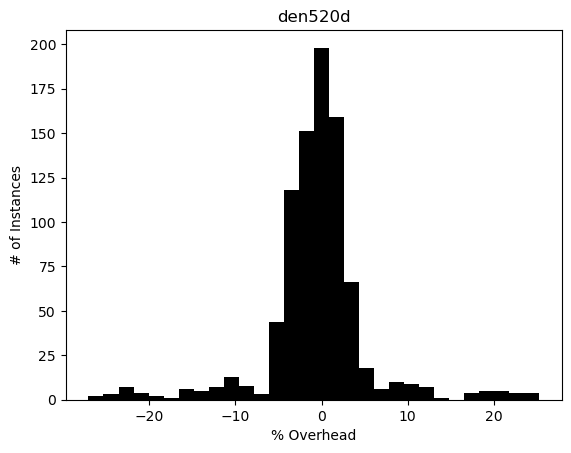

In [74]:
asipp_dat = data[data.algorithm == "asipp"]
sipp_dat = data[data.algorithm == "sipp"]

x = sipp_dat.sum_expanded
y = 200*(asipp_dat.runtime.values - sipp_dat.runtime.values) / (asipp_dat.runtime.values + sipp_dat.runtime.values)
print(np.mean(y), np.std(y))
#plt.plot(x, y, ".k", label = "SIPP")
plt.hist(y, 30, facecolor = "k")
#plt.plot(asipp_dat.sum_expanded, asipp_dat.sum_expanded/(asipp_dat.runtime / 1000), ".r", label = "ASIPP")

#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Frequency")
plt.xlabel("% Overhead")
plt.ylabel("# of Instances")
plt.title("den520d")
#plt.ylim([400000, 1000000])
#plt.legend()
plt.savefig("overhead_hist.png")

-0.4941947278732419 6.138141001196567


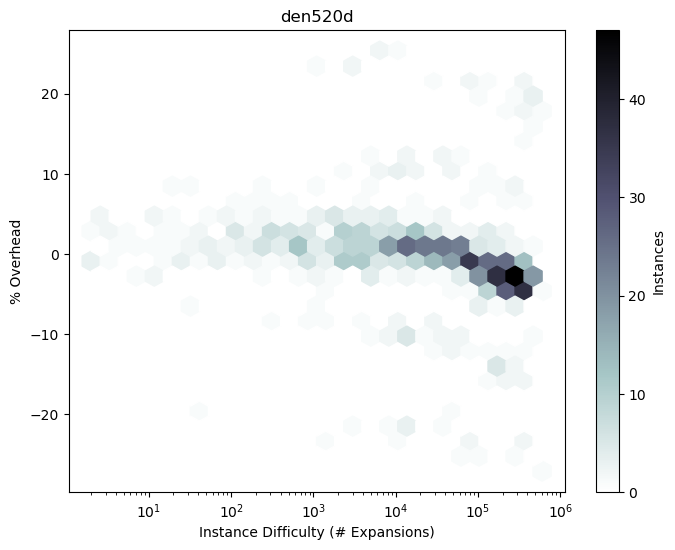

In [178]:
fig, ax0 = plt.subplots(ncols=1, figsize=(8, 6))
asipp_dat = data[data.algorithm == "asipp"]
sipp_dat = data[data.algorithm == "sipp"]

x = sipp_dat.sum_expanded
y = 200*(asipp_dat.runtime.values - sipp_dat.runtime.values) / (asipp_dat.runtime.values + sipp_dat.runtime.values)
print(np.mean(y), np.std(y))
hb = ax0.hexbin(x, y, gridsize=25, cmap='bone_r',  xscale = "log")
#plt.hist(y, 50, facecolor = "k")
#plt.plot(asipp_dat.sum_expanded, asipp_dat.sum_expanded/(asipp_dat.runtime / 1000), ".r", label = "ASIPP")

#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Instance Difficulty (# Expansions)")
plt.ylabel("% Overhead")
plt.title("den520d")
cb = fig.colorbar(hb, ax=ax0, label='Instances')

#plt.ylim([400000, 1000000])
#plt.legend()
plt.savefig("overheadvdiff.png")

In [95]:
dat = data[data.algorithm == "asipp"]
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime
1,maps/den520/den520d.map,asipp,0,140,226,13,74,17072,625,17073,1,20.685500
2,maps/den520/den520d.map,asipp,2,148,215,211,195,14535,444,14536,1,16.534200
3,maps/den520/den520d.map,asipp,1,100,41,122,35,478,20,219,1,0.426745
4,maps/den520/den520d.map,asipp,2,171,119,161,50,2807,179,1701,1,2.628950
6,maps/den520/den520d.map,asipp,2,94,173,14,189,48922,1672,48923,1,70.801700
...,...,...,...,...,...,...,...,...,...,...,...,...
7814,maps/den520/den520d.map,asipp,1,87,177,225,182,47563,1546,47564,1,64.926800
7815,maps/den520/den520d.map,asipp,1,217,71,143,95,43942,1504,43943,1,63.072300
7817,maps/den520/den520d.map,asipp,2,58,150,243,53,42398,1422,42399,1,57.592200
7819,maps/den520/den520d.map,asipp,0,127,168,152,45,38777,1456,38778,1,54.724700


In [105]:
# SIPP plans valid
valid_times = []
difficulty = []
for res in results:
    if res[1]["algorithm"] == "asipp":
        valid_times.append(float(res[1]['solution_compound_atf'][0]['interval'].replace("[", "").replace(")", "").split(",")[1]))
        difficulty.append(float(res[1]['results'][0]['metadata']['searchruntime_ms']))

Percent invalid
42.298850574712645


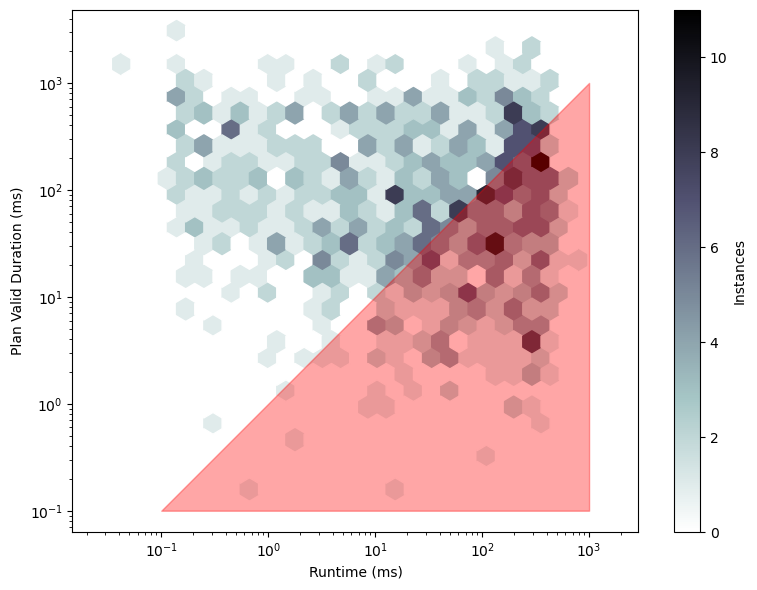

In [147]:
fig, ax0 = plt.subplots(ncols=1, figsize=(8, 6))
x = np.asarray(difficulty)
y = 1000*np.asarray(valid_times)
hb = ax0.hexbin(x, y,  gridsize=25, cmap='bone_r',  xscale = "log", yscale = "log")
plt.fill_between([10**-1, 10**3], [10**-1, 10**-1], [10**-1, 10**3], color = "r", alpha = 0.35)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Runtime (ms)")
plt.ylabel("Plan Valid Duration (ms)")
plt.axis("equal")
cb = fig.colorbar(hb, ax=ax0, label='Instances')

#plt.xlim([.1, 10**3])
plt.tight_layout()
plt.savefig("invalid.png")

print("Percent invalid")
print(100*(x > y).sum()/len(x))

In [104]:
results[2][1]['results'][0]['metadata']

{'generated': 486631,
 'decreased': 12239,
 'expanded': 470148,
 'learnexpanded': 0,
 'searchruntime_ms': 458.803,
 'learnruntime_ms': 0}

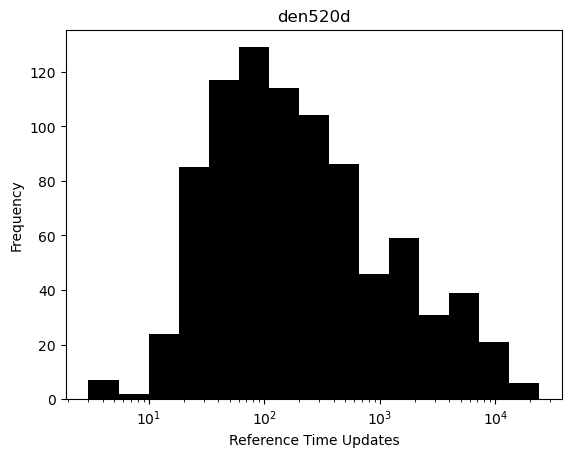

In [148]:
dat = data[data.algorithm == "repeat"]
logbins = np.geomspace(dat.n_tref.min(), dat.n_tref.max(), 16) 
plt.hist(dat.n_tref, bins = logbins, facecolor="k")
#plt.yscale("log")
plt.xscale("log")
plt.ylabel("Frequency")
plt.xlabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("plan-size.png")

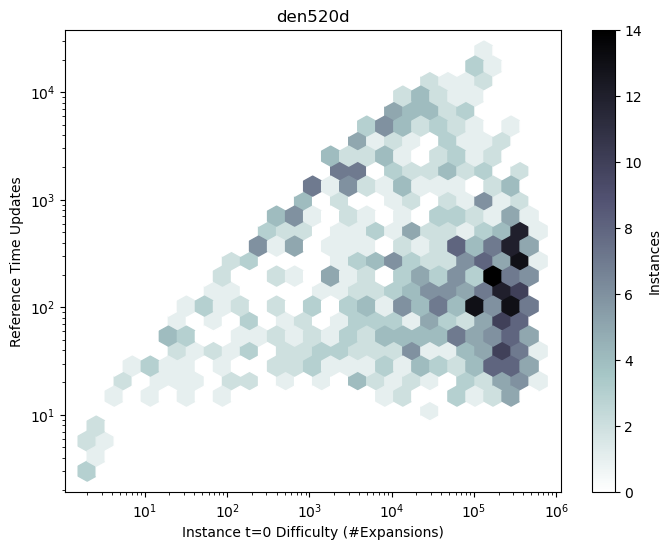

In [164]:
fig, ax0 = plt.subplots(ncols=1, figsize=(8, 6))
x = sipp_dat.sum_expanded.values
y = dat.n_tref.values
hb = ax0.hexbin(x, y,  gridsize=25, cmap='bone_r',  xscale = "log", yscale = "log")
#plt.plot(x, y, ".k")
cb = fig.colorbar(hb, ax=ax0, label='Instances')

plt.xlabel("Instance t=0 Difficulty (#Expansions)")
plt.ylabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("rtplan.png")

In [197]:
x = sipp_dat.sum_expanded.values
y = dat.runtime

lx = np.log10(x)
ly = np.log10(y)

p = np.polyfit(lx, ly, 1)
fit_x = np.logspace(0, 6, 10)
fit_y = 10**p[1] * np.power(fit_x, p[0])
print("y = {:1.2f}*x^{:1.2f}".format(10**p[1], p[0]))
print("y = " + str(10**p[1]) + "*x^" + str(p[0]))  

y = 0.81*x^0.89
y = 0.8095125383161212*x^0.8914016180543728


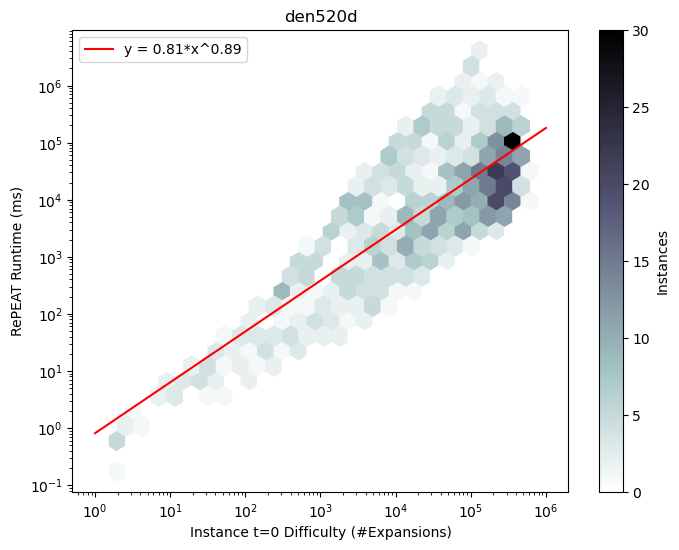

In [198]:
fig, ax0 = plt.subplots(ncols=1, figsize=(8, 6))

hb = ax0.hexbin(x, y,  gridsize=25, cmap='bone_r',  xscale = "log", yscale = "log")
plt.plot(fit_x, fit_y, "r", label = "y = {:1.2f}*x^{:1.2f}".format(10**p[1], p[0]))
cb = fig.colorbar(hb, ax=ax0, label='Instances')

plt.xlabel("Instance t=0 Difficulty (#Expansions)")
plt.ylabel("RePEAT Runtime (ms)")
plt.title("den520d")
plt.legend(loc = "upper left")
plt.savefig("repeatruntime.png")

In [159]:
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime,node,arrival_time,instance_id,replicate
1415,maps/den520/den520d.map,repeat,0,153,226,153,224,1608,0,9,3,0.446054,ai1,0.0,1,0
138,maps/den520/den520d.map,repeat,0,52,75,50,75,1658,0,6,3,0.497012,ai2,0.0,2,0
2429,maps/den520/den520d.map,repeat,0,93,228,92,225,7143,4,65,13,2.055607,ai3,0.0,3,0
2223,maps/den520/den520d.map,repeat,0,20,151,18,152,4453,1,34,8,1.285544,ai4,0.0,4,0
511,maps/den520/den520d.map,repeat,0,17,176,15,173,10507,8,175,19,3.181610,ai5,0.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,maps/den520/den520d.map,repeat,0,242,5,17,199,40731612,1608217,37064125,162,39866.156000,ai2,0.0,866,0
2154,maps/den520/den520d.map,repeat,0,10,204,78,36,125066600,3325679,119700228,294,121119.780000,ai15,0.0,867,0
2531,maps/den520/den520d.map,repeat,0,19,72,155,218,88705985,2464905,84904288,201,91783.325000,ai14,0.0,868,0
1076,maps/den520/den520d.map,repeat,0,66,38,20,210,52045026,1477474,49612644,130,49744.777000,ai13,0.0,869,0


In [173]:
stats.gmean(dat.n_tref), dat.n_tref.median(), dat.n_tref.max()

(np.float64(204.52859619271646), np.float64(159.5), np.int64(24056))